Customer churn refers to customers who have stopped using the company’s services.
In this dataset, the target variable **Churn** indicates whether a customer has left the service
(**Yes** , 1) or is still retained (**No**,0).

The objective of this project is to analyze customer characteristics and behavior
to understand the factors influencing churn and to build a predictive model
that can identify customers at risk of leaving.

**-> Importing all nessasary libraies**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [53]:
pd.set_option('display.max_columns', None)

# DATA UNDERSTANDING

**-> Displaying all columns & Five random rows**

In [2]:
df=pd.read_csv("tele_comm.csv")
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [3]:
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
3444,3739-YBWAB,Male,0,Yes,No,36,No,No phone service,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,35.35,1317.95,No
4840,5730-RIITO,Female,1,No,No,43,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Credit card (automatic),33.45,1500.25,No
1397,8714-CTZJW,Female,0,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,Yes,Month-to-month,Yes,Credit card (automatic),82.85,319.6,No
6906,9945-PSVIP,Female,0,Yes,Yes,25,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Mailed check,18.70,383.65,No
2697,6461-SZMCV,Female,0,Yes,No,71,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),87.95,6365.35,No


~ The dataset consists of customer identifiers, demographic features, service usage details, billing information, and a churn target variable, collectively used to analyze customer behavior and predict churn

**-> Enquiring the dimensions of dataset**

In [4]:
df.ndim

2

In [5]:
df.shape

(7043, 21)

~ Its a 2D data consisting of 7043 rows & 21 columns

**-> Trying to check the data_types & null_values in the dataset**

In [6]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


~ Only monthly_charges, tenure, senior_citizen are numeric, and as far no null values found

**-> classification of columns**

In [8]:
target = 'Churn'

In [9]:
identifier = 'customerID'

In [10]:
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [col for col in df.columns 
                        if col not in numerical_features + [target, identifier]]

  columns are classified for better analysis
 
- **Customer Identifier**
  - customerID (unique identifier, not useful for modeling)

- **Target Variable**
  - Churn (Yes / No)

- **Categorical Features**
  - Service usage, contract type, payment method, demographic attributes

- **Numerical Features**
  - Tenure
  - MonthlyCharges
  - TotalCharges
    

In [11]:
numerical_features

['tenure', 'MonthlyCharges', 'TotalCharges']

In [12]:
categorical_features

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

**-> Displaying the statistical measures of numerical data**

In [13]:
df[numerical_features].describe()

,tenure,MonthlyCharges
count,7043.000000,7043.000000
mean,32.371149,64.761692
std,24.559481,30.090047
min,0.000000,18.250000
25%,9.000000,35.500000
50%,29.000000,70.350000
75%,55.000000,89.850000
max,72.000000,118.750000


**-> Enquiring the target variable**

In [14]:
# churn value counts
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [15]:
# Churn percentage
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

The churn variable is moderately imbalanced, with a higher proportion of customers not churning.
This imbalance is typical in customer churn problems and will be considered during model evaluation

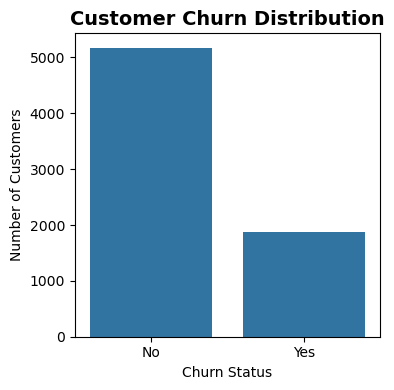

In [16]:
# churn visualization

plt.figure(figsize=(4, 4))
sns.countplot(x='Churn',data=df)
plt.title('Customer Churn Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

NOTE:
- The dataset contains customer demographic, service usage, and billing information.
- The target variable **Churn** is imbalanced.
- These insights guide the next steps of exploratory data analysis,
  feature engineering, and model selection.

# DATA CLEANING

**Checking if same customer info is re-recorded again**

**->(checking for duplicates)**

In [17]:
df.duplicated().sum()

0

~ no duplicate rows found

~ All records represent independent customers with no repeated observations.

In [18]:
df_cleaned=df.copy()

~ some changes that were to be made while cleaning may be permanant so it is suggested to copy the original data

**-> Converting binary categorical columns to numerical columns**

In [19]:
df_cleaned['gender'] = df_cleaned['gender'].map({'Male': 1, 'Female': 0})

~ **male** as 1 && **female** as 0

In [20]:
col=["Partner","Dependents","PhoneService","PaperlessBilling","Churn"]
for _ in col:
     df_cleaned[_]=df_cleaned[_].map({'Yes':1,'No':0})

~ Partner,Dependents,PhoneService,PaperlessBilling,Churn are binary categorical features (ie) they possess only yes,no values

**-> converting multi-class categorical features to numeric features using One Hot Encoding**

In [21]:
mClassCols=['Contract', 'InternetService', 'PaymentMethod', 
             'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
             'TechSupport', 'StreamingTV', 'StreamingMovies']
df_cleaned=pd.get_dummies(df_cleaned,columns=mClassCols,drop_first=True)

**-> converting Total_charges to numerical form**

In [22]:
df_cleaned['TotalCharges']=pd.to_numeric(df_cleaned['TotalCharges'],errors='coerce')

~ TotalCharges is a numerical column which is identified as object so, it is has to be converted as numeric

**-> checking for missing values**

In [23]:
df.replace({" ":np.nan},inplace=True)

In [24]:
df_cleaned.isnull().sum()

customerID                                0
gender                                    0
SeniorCitizen                             0
Partner                                   0
Dependents                                0
tenure                                    0
PhoneService                              0
PaperlessBilling                          0
MonthlyCharges                            0
TotalCharges                             11
Churn                                     0
Contract_One year                         0
Contract_Two year                         0
InternetService_Fiber optic               0
InternetService_No                        0
PaymentMethod_Credit card (automatic)     0
PaymentMethod_Electronic check            0
PaymentMethod_Mailed check                0
MultipleLines_No phone service            0
MultipleLines_Yes                         0
OnlineSecurity_No internet service        0
OnlineSecurity_Yes                        0
OnlineBackup_No internet service

~ After converting TotalCharges to numeric, 11 records are found to be missing (NAN)

**Replacing the null values in Totalcharges as the product of MonthlyCharges and tenure**

In [25]:
mark = df_cleaned['TotalCharges'].isnull()
df_cleaned.loc[mark, 'TotalCharges'] = (
    df_cleaned.loc[mark, 'MonthlyCharges'] * df_cleaned.loc[mark, 'tenure'])

In [26]:
df_cleaned['TotalCharges'].isnull().sum()

0

~ the null values were replaced successfully

**Removing customer_Id column**

In [27]:
df_cleaned.drop(columns=['customerID'], inplace=True)

~There is no semantic meaning in the characters that can explain churn.

~Models learn patterns, not identities.

**-> Checking for invalid values across data**

In [28]:
(df['tenure'] < 0).sum(), (df['MonthlyCharges'] < 0).sum()

(0, 0)

~ No invalid or impossible values (e.g., negative tenure or charges) were detected, ensuring data integrity.

**-> Identifying outliers**

In [29]:
df_cleaned[numerical_features].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


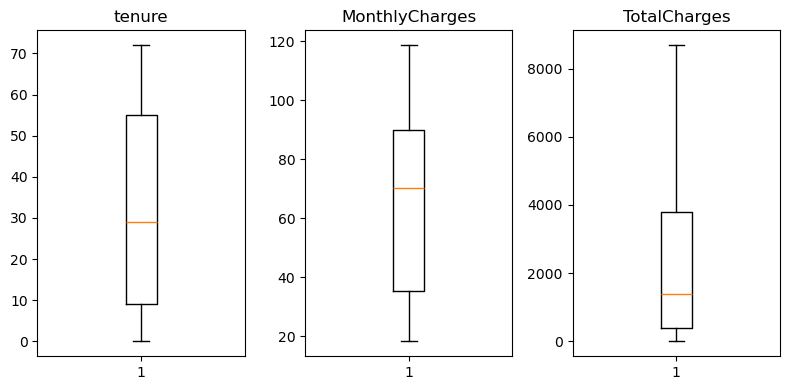

In [30]:
plt.figure(figsize=(8, 4))
for i, col in enumerate(numerical_features, 1):
    plt.subplot(1, 3, i)
    plt.boxplot(df_cleaned[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [31]:
#Outliers detection using IQR
def iqr_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

In [32]:
for col in numerical_features:
    outliers, lb, ub = iqr_outliers(df_cleaned, col)
    print(f"{col}")
    print(f"Lower Bound: {lb}, Upper Bound: {ub}")
    print(f"Number of Outliers: {outliers.shape[0]}")
    print("....." * 15)

tenure
Lower Bound: -60.0, Upper Bound: 124.0
Number of Outliers: 0
...........................................................................
MonthlyCharges
Lower Bound: -46.02499999999999, Upper Bound: 171.375
Number of Outliers: 0
...........................................................................
TotalCharges
Lower Bound: -4683.525, Upper Bound: 8868.675
Number of Outliers: 0
...........................................................................


**tenure**: Values range roughly from 0 to 72 months  
**monthly_charges**: Values range approximately from $18 to $120  
**TotalCharges**: Distribution is right-skewed      
                  *~ no outliers found*
                  


  The **Data Understanding** and **Cleaning** stages involved:  
- feature classification
- target assessment
- duplicate verification
- data type correction
- missing value handling
- categorical validation and data integrity checks.
  
These steps ensured the dataset was accurate, consistent, and suitable for exploratory analysis and modeling.  

# EXPLORATORY DATA ANALYSIS (Data Exploration)

The primary objective of EDA is to understand how customer characteristics differ between churned and non-churned customers, while first analyzing individual feature distributions independently.

In [33]:
sns.set_theme(
    context="talk",
    font_scale=0.6
)

### 1.CHURN OVERVIEW (target variable analysis)**

In [34]:
# churn distribution

df_cleaned['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

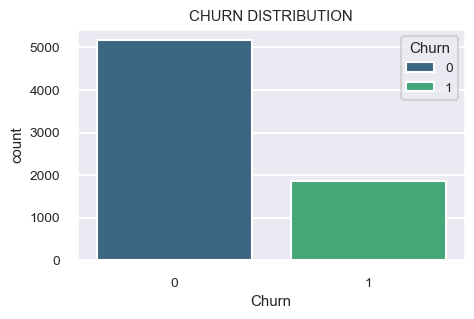

In [35]:
plt.figure(figsize=(5,3))
sns.countplot(data=df_cleaned,x='Churn',palette='viridis',hue='Churn')
plt.title('CHURN DISTRIBUTION')
plt.show()

In [36]:
# churn imbalance

df_cleaned['Churn'].value_counts(normalize='True')*100

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64

**checking class imbalance will guide the model choice later**  
~ Roughly 3 out of 4 customers do NOT churn  
~ About 1 out of 4 customers churn  
~ Ratio ≈ 3 : 1  

### 2.UNIVARIATE ANALYSIS (NUMERICAL) 
~ Analysis of one numerical variable at a time to understand its distribution, pattern, and basic characteristics.(**without churn segmentation**)

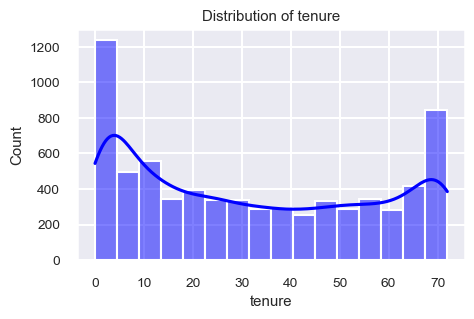

...........................................................................



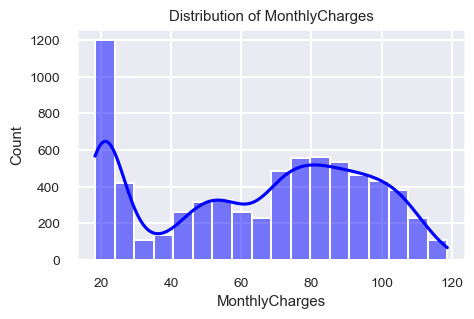

...........................................................................



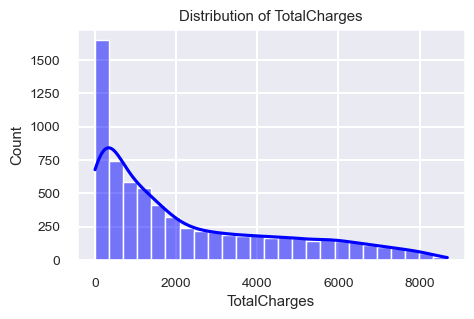

...........................................................................



In [37]:
# Distribution plots of numerical columns

for col in numerical_features:
    plt.figure(figsize=(5,3))
    sns.histplot(df_cleaned[col], kde=True,color='blue')
    plt.title(f"Distribution of {col}")
    plt.show()
    print("....."*15)
    print()

**Univariate Numerical Analysis – Insights**

- **Tenure:** Distribution is bimodal with many new and long-tenure customers, indicating early churn exposure and long-term retention segments.
- **MonthlyCharges:** Values show a slightly right-skewed distribution, reflecting different pricing tiers and fewer high-charge customers.
- **TotalCharges:** Distribution is heavily right-skewed with a large concentration near lower values, indicating many low lifetime-value customers and a few high-value ones.

**Overall Insight**
Numerical features are non-normally distributed with noticeable skewness, highlighting the presence of pricing tiers, early customer drop-off, and revenue concentration among long-tenure customers.


### 3.UNIVARIATE ANALYSIS (CATEGORICAL)
~ Analysis of one categorical variable at a time to understand its distribution, pattern, and basic characteristics..(**without churn segmentation**)

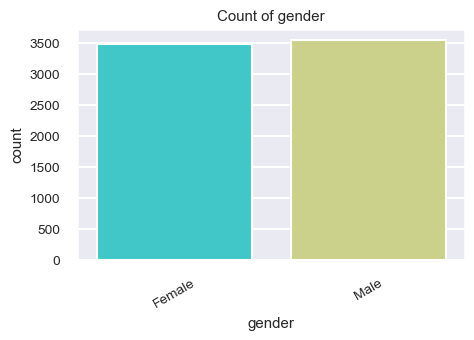

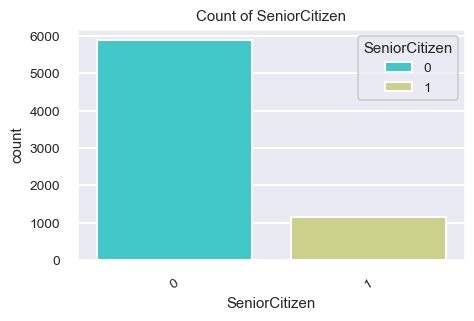

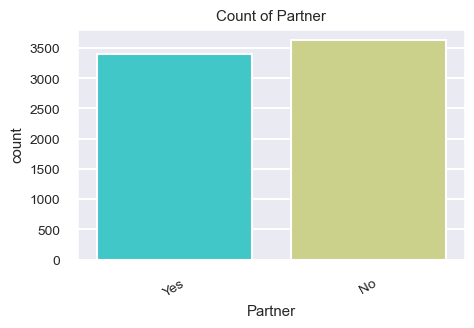

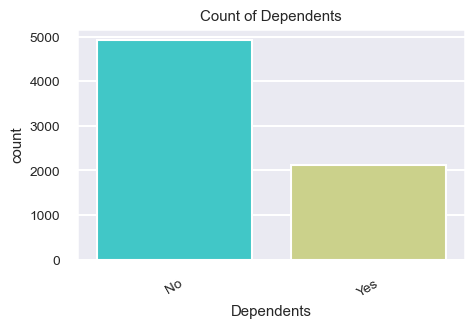

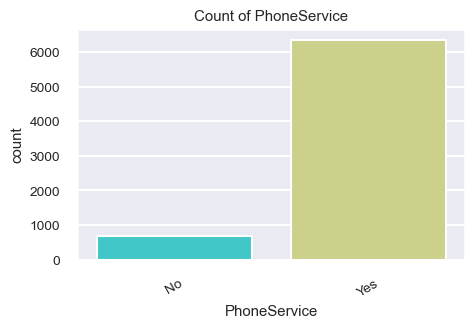

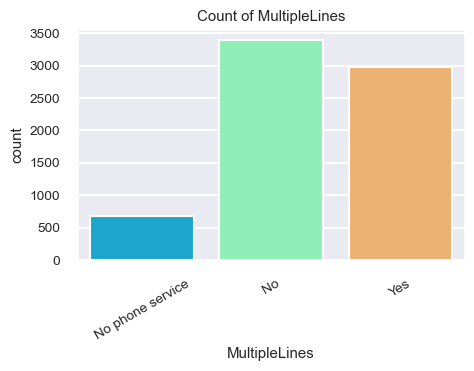

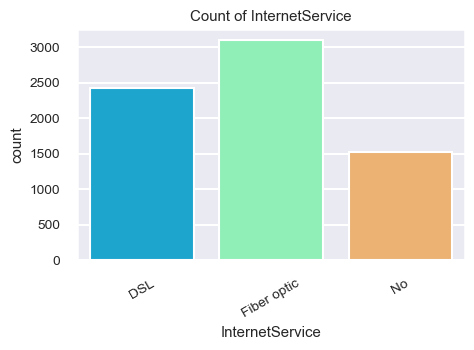

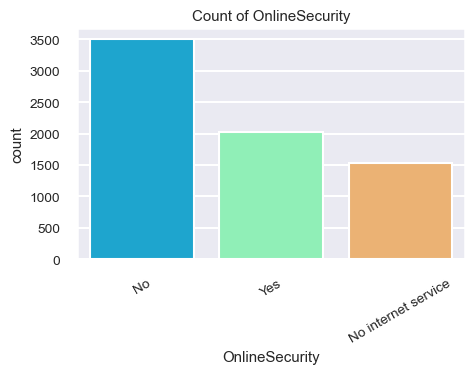

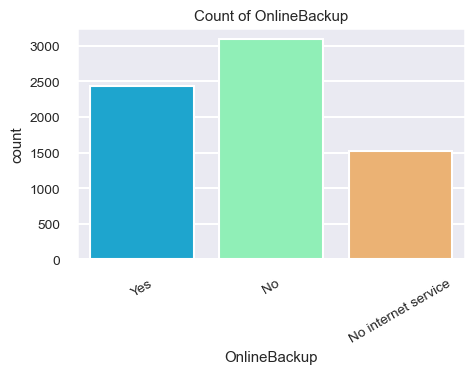

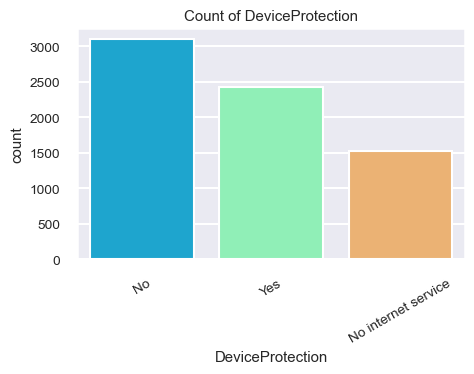

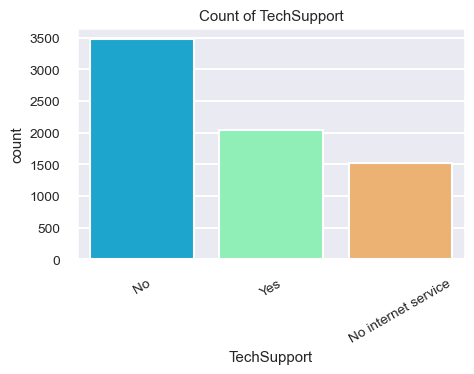

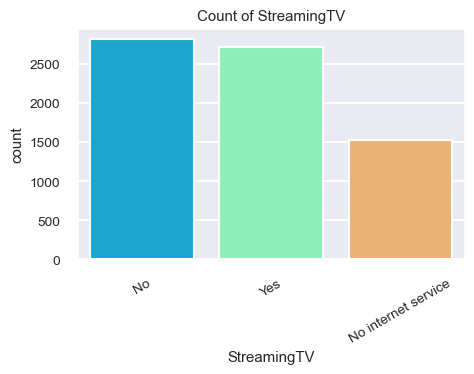

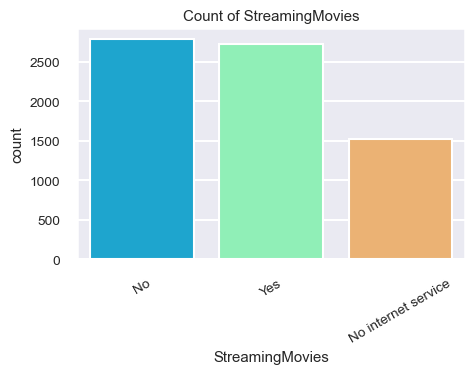

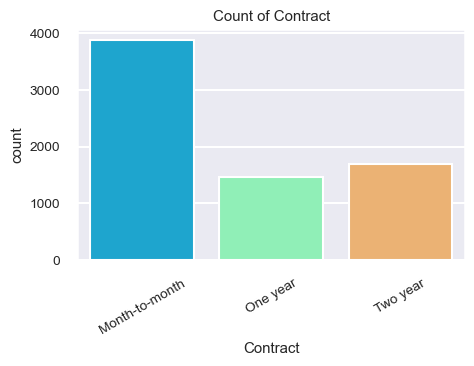

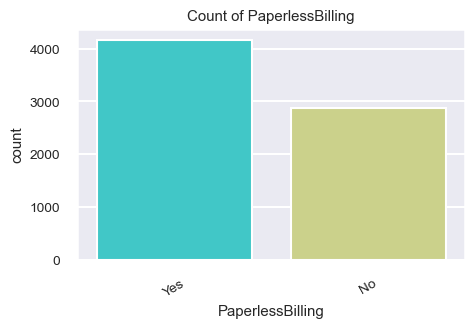

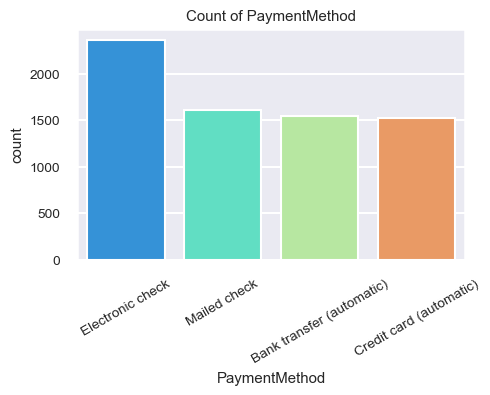

In [38]:
# Distribution plots of categorical columns

for col in categorical_features:
    plt.figure(figsize=(5,3))
    sns.countplot(data=df, x=col,hue=col, palette='rainbow')
    plt.title(f'Count of {col}')
    plt.xticks(rotation=30)
    plt.show()


**Gender:**  
Distribution is nearly balanced, indicating no strong dominance of a single gender.  
**SeniorCitizen:**  
Majority of customers are non-senior citizens, showing an imbalanced age category.  
**Partner:**  
Customers without partners slightly outnumber those with partners.  
**Dependents:**  
Most customers do not have dependents, indicating skew toward independent households.  
**PhoneService:**  
Phone service is used by the vast majority of customers.  
**MultipleLines:**  
Most customers do not use multiple lines, with a small group having no phone service.  
**InternetService:**  
Fiber optic is the most common internet service, followed by DSL.  
**OnlineSecurity:**  
More customers have not subscribed to online security services.  
**OnlineBackup:**  
Online backup adoption is lower compared to non-adoption.  
**DeviceProtection:**  
Majority of customers have not opted for device protection.  
**TechSupport:**  
Tech support usage is relatively low among customers.  
**StreamingTV:**  
Streaming TV usage is fairly balanced with a slight dominance of non-users.  
**StreamingMovies:**  
Streaming movie services show similar adoption patterns to streaming TV.  
**Contract:**  
Month-to-month contracts dominate, indicating preference for short-term plans.  
**PaperlessBilling:**  
Most customers have enabled paperless billing.  
**PaymentMethod:**  
Electronic check is the most frequently used payment method.

**Overall Insight**
Categorical features exhibit varying degrees of dominance and imbalance, reflecting diverse customer service usage and contract preferences, with no abnormal or invalid categories observed.


### 4.BIVARIATE ANALYSIS (NUMERICAL VS CHURN)  
~ Bivariate analysis of numerical variables is the process of analyzing two numerical features together to understand the nature, direction, and strength of the relationship between them. (**with churn segmentation ie churn variable includes**)

<Figure size 300x400 with 0 Axes>

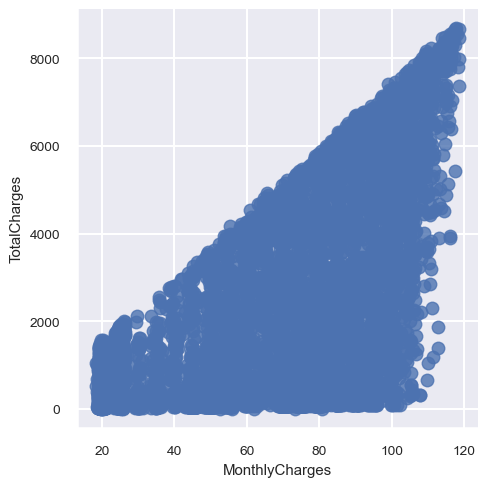

In [39]:
plt.figure(figsize=(3,4))
sns.lmplot(data=df_cleaned, x='MonthlyCharges', y='TotalCharges',fit_reg=False)
plt.show()

~ TotalCharges increases as monthly charges increses (Expected)

**Numerical features vs churn**

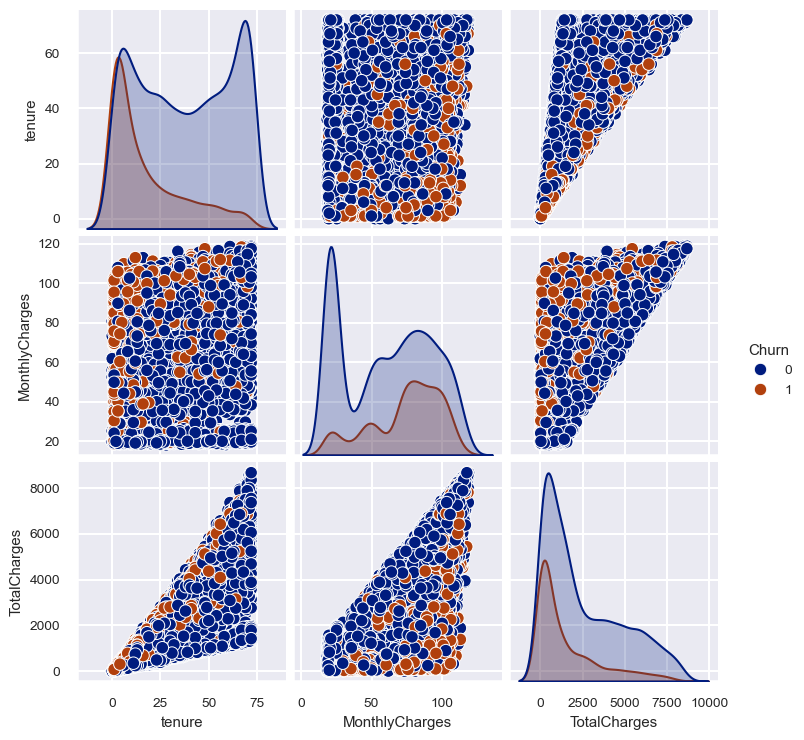

In [40]:
sns.pairplot(
    df_cleaned,
    vars=['tenure', 'MonthlyCharges', 'TotalCharges'],
    hue='Churn',
    palette='dark'
)
plt.show()

 **Tenure is the strongest indicator of churn**  
  Customers with **low tenure** are significantly more likely to churn, whereas customers with **longer tenure rarely churn**.

 **Monthly Charges show price sensitivity**  
  Churned customers generally have **higher monthly charges**, suggesting that customers are more likely to leave when they perceive the service as expensive early on.

 **Total Charges reflect customer lifetime**  
  Customers who churn tend to have **lower total charges**, indicating they leave **early in their customer lifecycle** before accumulating high overall spending.

 **Tenure and Total Charges are strongly correlated**  
  The clear linear pattern confirms that **customer lifetime value is driven mainly by retention duration**, not just monthly pricing.

 **Key Business Insight**  
  **New customers with high monthly charges are the most vulnerable segment** and should be prioritized for **early engagement and retention strategies**.

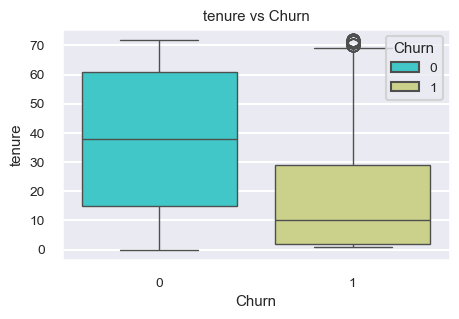

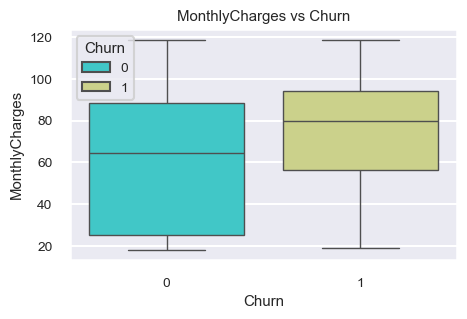

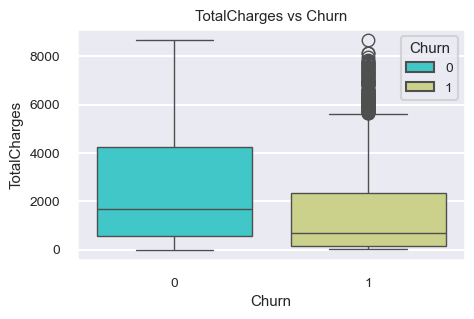

In [41]:
for col in numerical_features:
    plt.figure(figsize=(5,3))
    sns.boxplot(x='Churn',y=col,data=df_cleaned,hue='Churn',palette="rainbow",showfliers=True)
    plt.title(f"{col} vs Churn")
    plt.show()

**tenure:**  
 Churn is highest among customers with low tenure.  
 Customers who stay longer are unlikely to churn.  
 Tenure is a key indicator of customer retention.  
  
**MonthlyCharges:**  
Churned customers generally have higher monthly charges.  
Lower monthly charges are associated with better customer retention.  
MonthlyCharges is an important factor influencing churn.  

**TotalCharges:**  
Churned customers typically have low total charges.  
Non-churned customers accumulate higher total charges over time.  
TotalCharges is strongly linked to customer tenure and churn behavior. 

**OVERALL INSIGHT:**  
Churn is concentrated among customers with low tenure, high monthly charges, and low total charges.  
Long-tenure customers with accumulated total charges show strong retention behavior.  
Tenure and pricing-related features are key drivers influencing customer churn.

### 5.BIVARIATE ANALYSIS (CATEGORICAL VS CHURN)

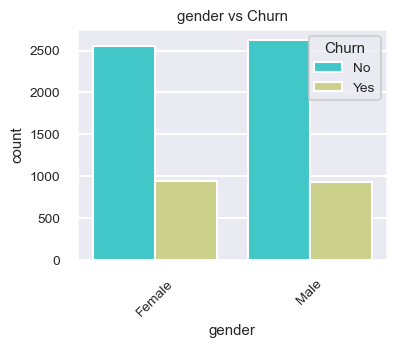

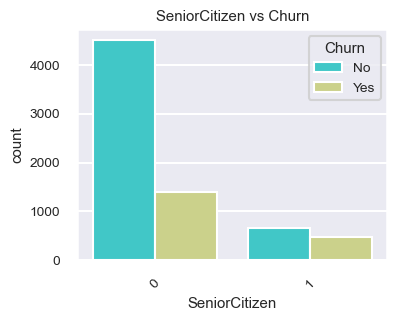

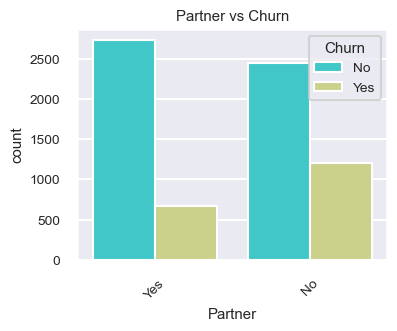

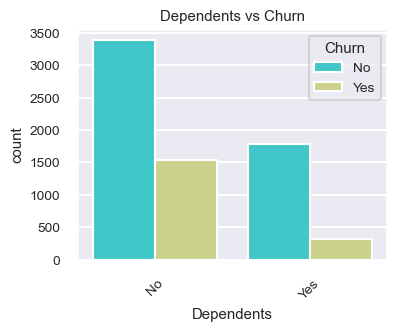

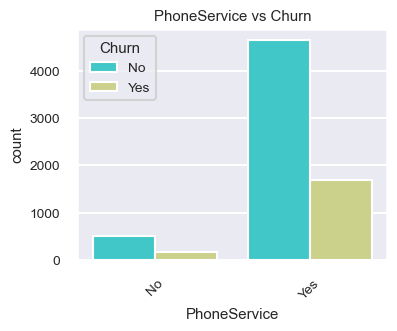

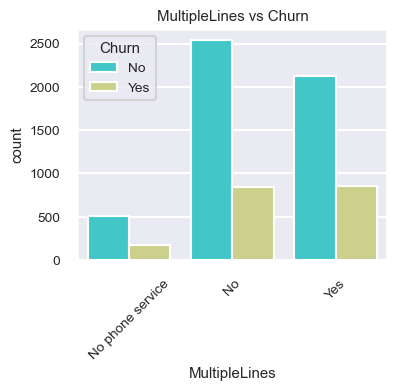

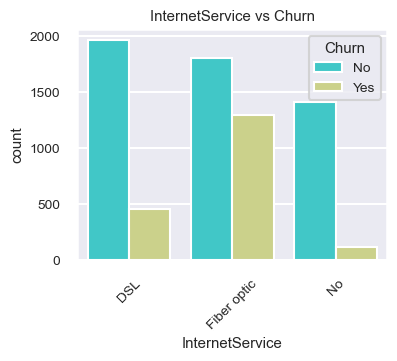

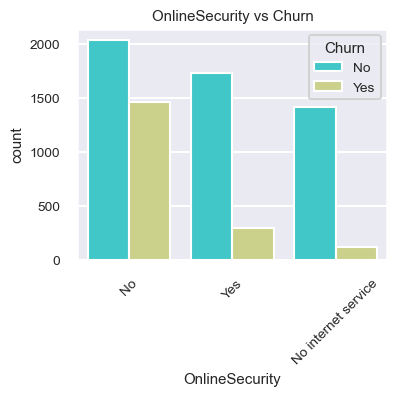

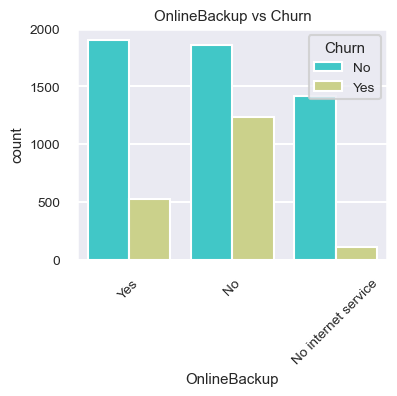

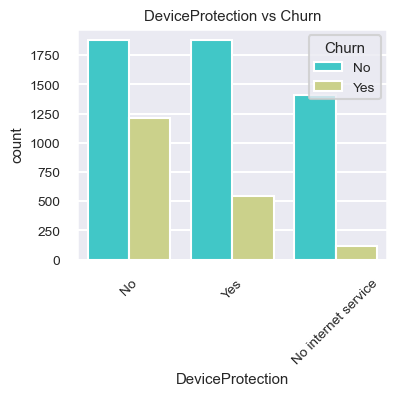

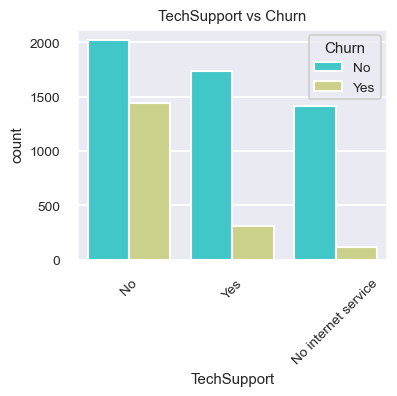

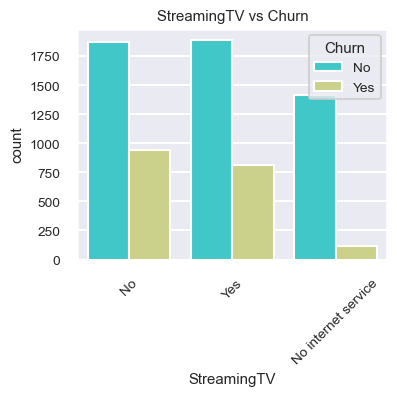

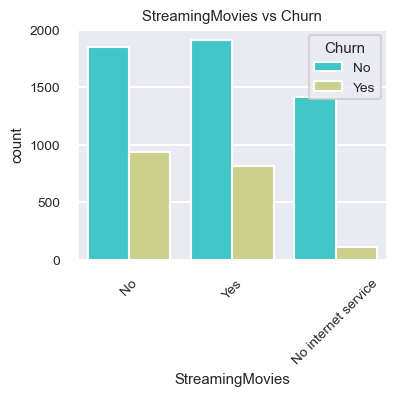

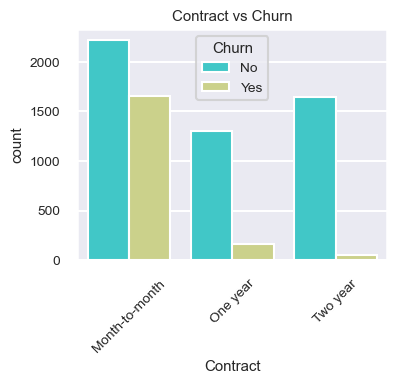

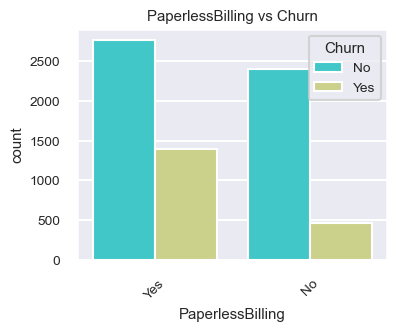

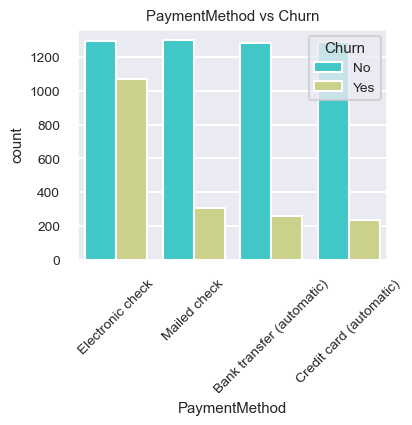

In [42]:
for col in categorical_features:
    plt.figure(figsize=(4,3))
    sns.countplot(x=col, hue='Churn', data=df,palette='rainbow')
    plt.xticks(rotation=45)
    plt.title(f'{col} vs Churn')
    plt.show()


  **Gender:** Churn rates are nearly identical across genders, indicating no meaningful impact.  
**Senior Citizen:** Senior citizens churn at a noticeably higher rate than non-senior customers.  
**Partner:** Customers without a partner exhibit higher churn compared to those with partners.  
**Dependents:** Customers without dependents churn significantly more than those with dependents.  
**Phone Service:** Phone service subscription shows minimal influence on churn behavior.  
**Multiple Lines:** Having multiple lines does not significantly affect churn likelihood.  
**Internet Service:** Fiber optic users show significantly higher churn than DSL and no-internet users.  
**Online Security:** Customers without online security services churn substantially more.  
**Online Backup:** Lack of online backup is associated with increased churn.  
**Device Protection:** Customers without device protection plans exhibit higher churn.  
**Tech Support:** Absence of tech support services strongly correlates with higher churn.  
**Streaming TV:** Streaming TV subscription has minimal impact on churn.  
**Streaming Movies:** Streaming movie services show little to no effect on churn.  
**Contract:** Month-to-month contracts have the highest churn, while two-year contracts have the lowest.  
**Paperless Billing:** Paperless billing users tend to churn more than traditional billing users.  
**Payment Method:** Electronic check users show the highest churn, while automatic payments reduce churn.

**OVERALL INSIGHT:**    
Churn is higher among senior citizens, customers without partners or dependents, and those on month-to-month contracts.  
Service-related factors such as fiber optic internet, lack of security/backup/support services, and electronic check payments are strongly associated with higher churn.  
Demographic factors like gender and add-on services such as streaming show minimal impact on churn behavior.

### 6.MULTIVARIATE ANALYSIS  
It helps answer how several features together influence an outcome (e.g., churn), and how they interact with each other.

**Correlation Heatmap (Numerical Features + Churn)**

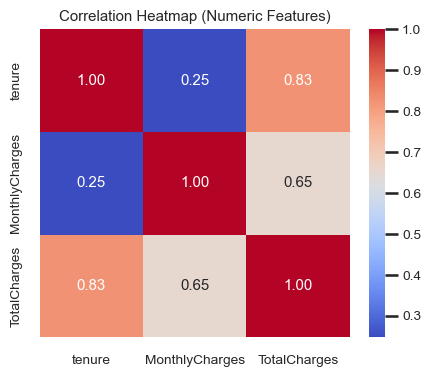

In [43]:
plt.figure(figsize=(5,4))
sns.heatmap(df_cleaned[numerical_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Numeric Features)')
plt.show()

Customer churn is most strongly influenced by tenure—customers who stay longer are significantly less likely to churn.  
Higher monthly charges slightly increase churn risk, suggesting price sensitivity among customers.  
Total charges show lower churn mainly because they reflect long-term customer retention, reinforcing that early-stage customers with higher bills are the most vulnerable to churn.

<Axes: >

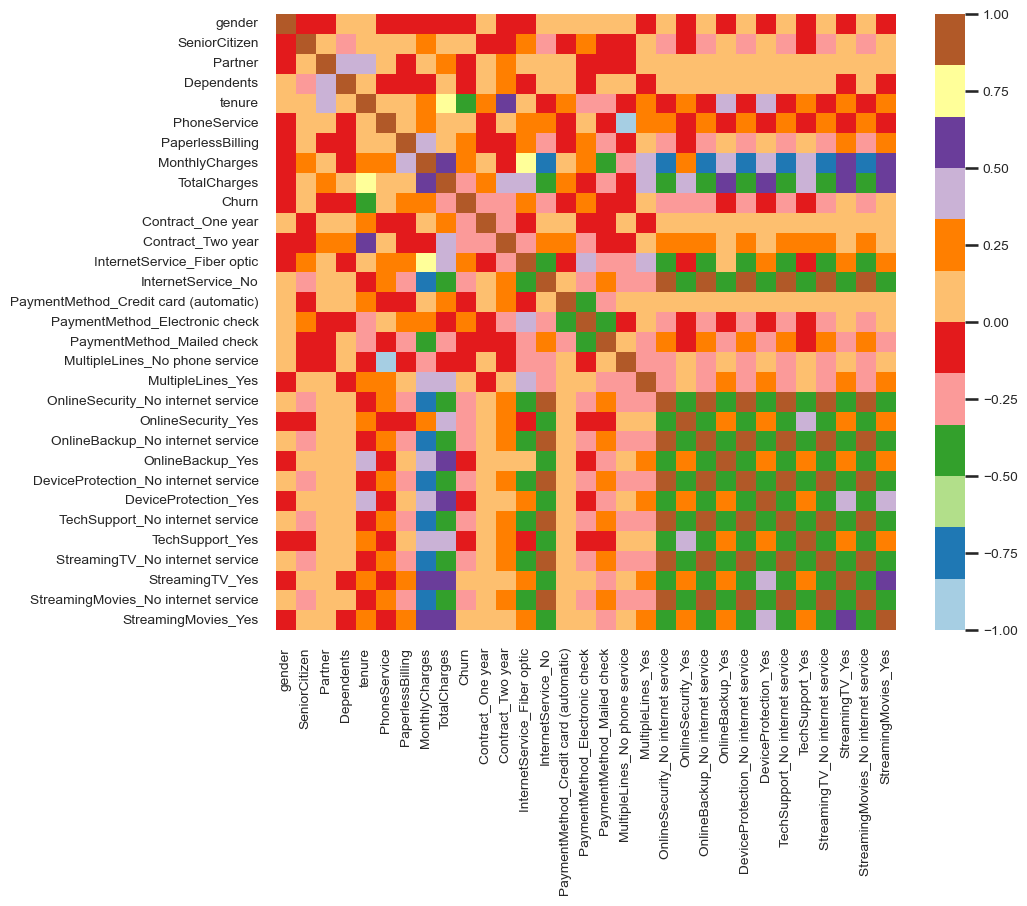

In [44]:
plt.figure(figsize=(10,8))
sns.heatmap(df_cleaned.corr(), cmap="Paired")

<Axes: >

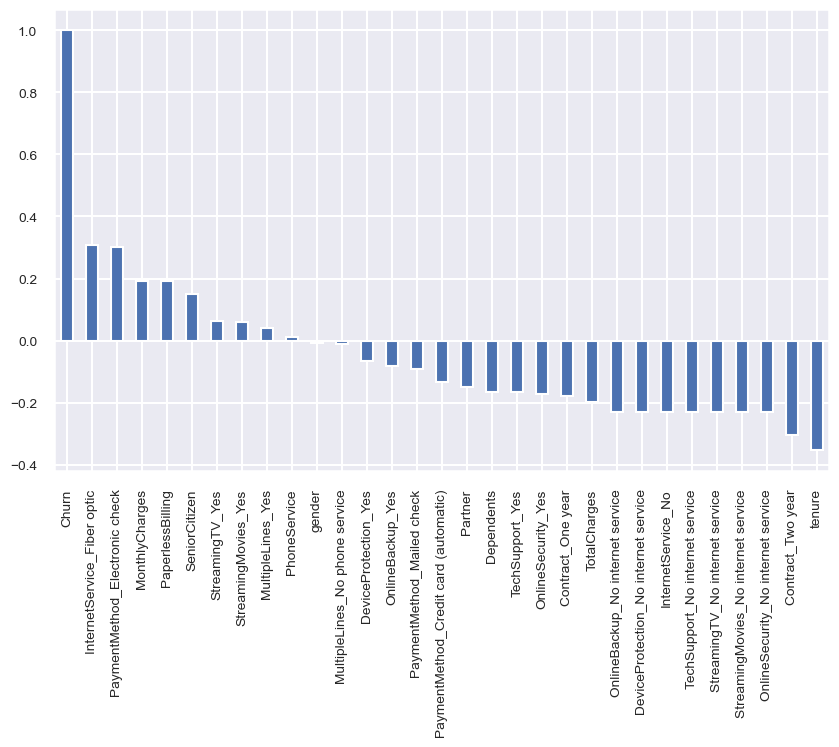

In [45]:
plt.figure(figsize=(10,6))
df_cleaned.corr()['Churn'].sort_values(ascending = False).plot(kind='bar')

**HIGH** Churn seen in case of Month to month **contracts, No online security, No Tech support, First year of subscription and Fibre Optics Internet**  
**LOW** Churn is seens in case of **Long term contracts, Subscriptions without internet service** and **The customers engaged for 5+ years**  
Factors like **Gender, Availability of PhoneService** and  **multiple lines** have alomost **NO** impact on Churn  
This is also evident from the **Heatmap** above

 
- Churn behavior is influenced by **a combination of demographic, service, and billing factors**, rather than a single feature.
- Interactions between tenure, charges, and contract type provide deeper insights into churn patterns.
- Multivariate relationships highlight the importance of **feature interaction modeling** for accurate churn prediction.


### EDA CONCLUSION
1. Customers using **Electronic Check** as a payment method show the **highest churn rate**, indicating possible trust or convenience issues with this mode.

2. **Month-to-Month contract customers** are significantly more likely to churn compared to customers with one-year or two-year contracts, as they have **no long-term commitment**.

3. Customers **without Online Security** and **without Tech Support** services exhibit **higher churn**, suggesting that lack of service protection and assistance reduces customer retention.

4. **Non-Senior Citizens** show a higher churn rate compared to senior citizens, possibly due to greater price sensitivity or availability of alternatives.

5. Customers with **short tenure** are much more likely to churn, indicating that **early customer experience** is critical for retention.

6. **Higher monthly charges** are associated with higher churn, especially when not accompanied by value-added services.

7. Customers with **fiber optic internet service** tend to churn more compared to DSL users, possibly due to pricing or service expectations.

8. **Automatic payment methods** (credit card or bank transfer) are linked with **lower churn**, suggesting that convenience and automation improve customer stickiness.

9. Customers **without add-on services** such as device protection, streaming services, or online backup show a higher tendency to churn.

10. **Long-term contract customers** (1-year and 2-year) demonstrate strong retention, highlighting the importance of contractual engagement strategies.

11. Customers with **multiple services bundled together** are less likely to churn than customers subscribed to a single service.

12. **Higher total charges combined with longer tenure** generally indicate loyal customers, while high charges with short tenure correlate with churn.

---


Churn is influenced by a **combination of pricing, service quality, contract commitment, and customer engagement**. Customers who are less committed, lack support services, or experience higher costs early in their lifecycle are more prone to churn.

These insights can directly guide **feature engineering, retention strategies, and churn prediction modeling**.
